**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 06. Optimization and Root Finding with Numerics
This notebook covers optimization and root finding methods in Numerics.

## What You'll Learn
- Root finding (Bisection, Brent's method)
- Numerical integration
- Local optimization (Nelder-Mead, BFGS, Powell)
- Global optimization (DE, MS, MLSL, Particle Swarm, SCE, Simulated Annealing)
- Practical applications

## When to Use Optimization vs MCMC

**Use Optimization when:**
- You need point estimatest only (no uncertainty)
- Computational speed is critical
- You have a well-defined objective function

**Use MCMC when:**
- You need uncertainty quantification
- You want full posterior distributions
- You have prior information to incorporate

## Setup

In [11]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from System import Func, Double, Array
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Mathematics.Optimization import (NelderMead, BFGS, Powell, ParticleSwarm, SimulatedAnnealing, AugmentedLagrange, 
DifferentialEvolution, MultiStart, LocalMethod, ShuffledComplexEvolution, MLSL, ConstraintType, IConstraint, Constraint)
from Numerics.Mathematics.RootFinding import Bisection, Brent
from Numerics.Mathematics.Integration import Integration

print("✓ Setup complete")

✓ Setup complete


## 1. Root Finding

**Problem:** Find x where f(x) = 0

### Methods Available:
- Bisection
- Brent
- Newton Raphson
- Secant

### Example: Quadratic Function

Find the root of f(x) = x² - 2 (true root: √2 ≈ 1.414)

We will explore the Bisection and Brent root finding method.

Root-finding results for f(x)=x^2 -2


,Method,Found Root,True Root,Abs Error,f(root)
0,Bisection,1.414214,1.414214,1.851493e-09,-5.236811e-09
1,Brent,1.414214,1.414214,1.961986e-12,-5.549117e-12


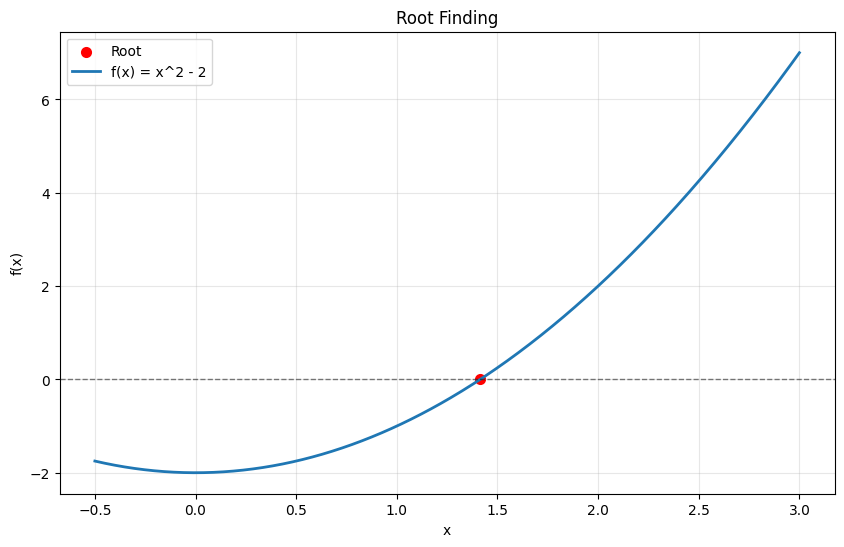

In [ ]:
# Define the function
def quadratic(x):
    """f(x) = x^2 - 2"""
    return x * x - 2.0

quadratic_func = Func[Double, Double](quadratic)
root = Bisection.Solve(quadratic_func, 1.0, 0.0, 4.0)
root_brent = Brent.Solve(quadratic_func, 0.0, 4.0)
true_root = np.sqrt(2.0)

root_df = pd.DataFrame([
    {'Method': 'Bisection', 'Found Root': root, 'True Root': true_root, 'Abs Error': abs(root - true_root), 'f(root)': quadratic(root)},
    {'Method': 'Brent', 'Found Root': root_brent, 'True Root': true_root, 'Abs Error': abs(root_brent - true_root), 'f(root)': quadratic(root_brent)},
])
print('Root-finding results for f(x)=x^2 -2')
display(root_df)

x = np.linspace(-0.5, 3, 500)
y = [quadratic(xi) for xi in x]
plt.figure(figsize=(10, 6))
plt.scatter(np.sqrt(2),0, color = 'red', label = 'Root', linewidths=5)
plt.plot(x, y, linewidth=2, label='f(x) = x^2 - 2')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('x'); plt.ylabel('f(x)'); plt.title('Root Finding Example 1'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

### Performance Comparison: Numerics vs SciPy
We take a look at how fast Numerics root finding methods are against the Python implementation in the "scipy package". Here Numerics is a little slower, but it still a comparable speed.

In [13]:
try:
    from scipy.optimize import root_scalar
    
    # Time Numerics
    start = time.perf_counter()
    root_numerics = Bisection.Solve(quadratic_func, 1, 0, 4)
    time_numerics = time.perf_counter() - start
    
    # Time SciPy
    start = time.perf_counter()
    result_scipy = root_scalar(quadratic, bracket=(1, 4), method='bisect', xtol=1e-8)
    root_scipy = result_scipy.root
    time_scipy = time.perf_counter() - start
    
    print("PERFORMANCE COMPARISON: Root Finding")
    print(f"Numerics Bisection:  {time_numerics*1000:.4f} ms  →  root = {root_numerics:.10f}")
    print(f"SciPy Bisection:     {time_scipy*1000:.4f} ms  →  root = {root_scipy:.10f}")
    print(f"Difference:          {abs(root_numerics - root_scipy):.2e}")
    
except ImportError:
    print("SciPy not installed. Skipping comparison.")

PERFORMANCE COMPARISON: Root Finding
Numerics Bisection:  0.0926 ms  →  root = 1.4142135605
SciPy Bisection:     0.0829 ms  →  root = 1.4142135661
Difference:          5.59e-09


### Additional Root Finding Examples

Let's try more complex functions.

Root-finding comparison table


,Function,Method,Root,f(root),Abs Error vs True
0,2sin(x)-3cos(x)-0.5,Bisection,1.121917,-7.880528e-09,2.984851e-05
1,2sin(x)-3cos(x)-0.5,Brent,1.121917,8.223644e-12,2.984630e-05
2,exp(-x)-x,Bisection,0.567143,-1.293185e-09,8.251863e-10
3,exp(-x)-x,Brent,0.567143,5.548373e-11,3.540435e-11


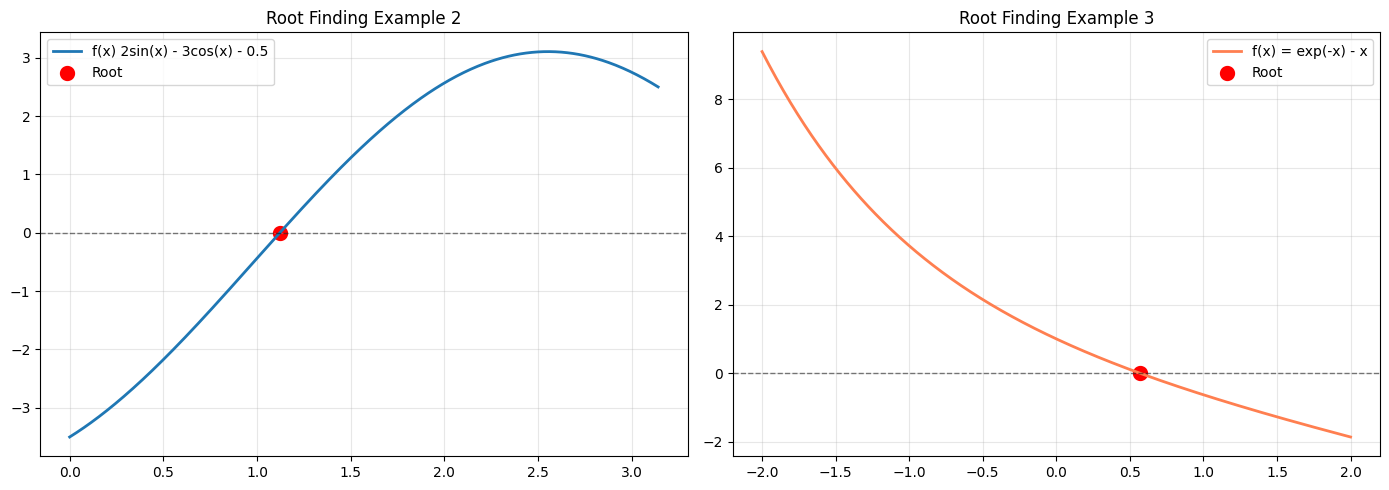

In [29]:
# Trigonometric function: 2sin(x) - 3cos(x) - 0.5
def trig_func(x):
    return 2*np.sin(x) - 3*np.cos(x) - 0.5

trig_func_net = Func[Double, Double](trig_func)
root_trig = Bisection.Solve(trig_func_net, 0.5, 0.0, np.pi)
root_trig_brent = Brent.Solve(trig_func_net, 0.0, np.pi)
true_root_trig = 1.1219469809174553

def exp_func(x):
    return np.exp(-x) - x

exp_func_net = Func[Double, Double](exp_func)
root_exp = Bisection.Solve(exp_func_net, 1.0, -2.0, 2.0)
root_exp_brent = Brent.Solve(exp_func_net, -2.0, 2.0)
true_root_exp = 0.5671432904097838

results_df = pd.DataFrame([
    {'Function': '2sin(x)-3cos(x)-0.5', 'Method': 'Bisection', 
     'Root': root_trig, 
     'f(root)': trig_func(root_trig), 
     'Abs Error vs True': abs(root_trig - true_root_trig)},
    {'Function': '2sin(x)-3cos(x)-0.5', 'Method': 'Brent',    
     'Root': root_trig_brent, 
     'f(root)': trig_func(root_trig_brent), 
     'Abs Error vs True': abs(root_trig_brent - true_root_trig)},
    {'Function': 'exp(-x)-x',           'Method': 'Bisection', 
     'Root': root_exp, 
     'f(root)': exp_func(root_exp), 
     'Abs Error vs True': abs(root_exp - true_root_exp)},
    {'Function': 'exp(-x)-x',           'Method': 'Brent',    
     'Root': root_exp_brent, 
     'f(root)': exp_func(root_exp_brent), 
     'Abs Error vs True': abs(root_exp_brent - true_root_exp)},
])

print('Root-finding comparison table')
display(results_df)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x1 = np.linspace(0, np.pi, 500)
ax1.plot(x1, [trig_func(xi) for xi in x1], linewidth=2, label = 'f(x) 2sin(x) - 3cos(x) - 0.5' )
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.scatter(true_root_trig, 0, color = 'red', linewidths=5, label='Root')
ax1.set_title('Root Finding Example 2'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.legend()

x2 = np.linspace(-2, 2, 500)
ax2.plot(x2, [exp_func(xi) for xi in x2], linewidth=2, color='coral', label = 'f(x) = exp(-x) - x')
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.scatter(true_root_exp, 0, color = 'red', linewidths=5, label = 'Root')
ax2.set_title('Root Finding Example 3'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout(); plt.show()

## 2. Numerical Integration

Compute definite integrals numerically when analytical integration is unavailable or inconvenient.

### Methods Available
- Gauss-Legendre quadrature: High accuracy for smooth functions with few evaluations.
- Trapezoidal rule: Simple baseline method with linear convergence.
- Simpson's rule: Higher-order rule using quadratic interpolation.
- Midpoint method: Simple and often slightly better than trapezoidal for smooth functions.

In [15]:
def f_x3(x):
    return x**3

f_x3_net = Func[Double, Double](f_x3)

gauss = Integration.GaussLegendre(f_x3_net, 0, 1)
trapz = Integration.TrapezoidalRule(f_x3_net, 0, 1, 1000)
simps = Integration.SimpsonsRule(f_x3_net, 0, 1, 1000)
midpt = Integration.Midpoint(f_x3_net, 0, 1, 1000)

true_value = 0.25
int_df = pd.DataFrame([
    {'Method':'Gauss-Legendre','Result':gauss,'Abs Error':abs(gauss-true_value)},
    {'Method':'Trapezoidal','Result':trapz,'Abs Error':abs(trapz-true_value)},
    {'Method':"Simpson's Rule",'Result':simps,'Abs Error':abs(simps-true_value)},
    {'Method':'Midpoint','Result':midpt,'Abs Error':abs(midpt-true_value)},
])
print('Integration of x^3 from 0 to 1')
display(int_df)

Integration of x^3 from 0 to 1


,Method,Result,Abs Error
0,Gauss-Legendre,0.25,0.000000e+00
1,Trapezoidal,0.25,2.500000e-07
2,Simpson's Rule,0.25,1.665335e-16
3,Midpoint,0.25,1.250000e-07


### Integration Performance: Numerics vs SciPy
We take a look at how fast Numerics integration methods are against Python's implementations in the "scipy" package. We can see that Numerics is a little slower, but the differences are comparable.

In [16]:
try:
    from scipy import integrate

    start = time.perf_counter(); result_numerics_gauss = Integration.GaussLegendre(f_x3_net, 0, 1); time_numerics_gauss = time.perf_counter() - start
    start = time.perf_counter(); result_numerics_simps = Integration.SimpsonsRule(f_x3_net, 0, 1, 1000); time_numerics_simps = time.perf_counter() - start

    start = time.perf_counter(); result_scipy_quad, _ = integrate.quad(f_x3, 0, 1); time_scipy_quad = time.perf_counter() - start
    x_pts = np.linspace(0, 1, 1001); y_pts = [f_x3(xi) for xi in x_pts]
    start = time.perf_counter(); result_scipy_simps = integrate.simpson(y_pts, x_pts); time_scipy_simps = time.perf_counter() - start

    perf_df = pd.DataFrame([
        {'Family':'Gauss/Quad','Library':'Numerics','Method':'Gauss-Legendre','Time (ms)':time_numerics_gauss*1000,'Result':result_numerics_gauss},
        {'Family':'Gauss/Quad','Library':'SciPy','Method':'quad','Time (ms)':time_scipy_quad*1000,'Result':result_scipy_quad},
        {'Family':'Simpson','Library':'Numerics','Method':'Simpson','Time (ms)':time_numerics_simps*1000,'Result':result_numerics_simps},
        {'Family':'Simpson','Library':'SciPy','Method':'simpson','Time (ms)':time_scipy_simps*1000,'Result':result_scipy_simps},
    ])
    print('Performance comparison: integration (Numerics vs SciPy)')
    display(perf_df)
except ImportError:
    print('SciPy not installed. Skipping comparison.')

Performance comparison: integration (Numerics vs SciPy)


,Family,Library,Method,Time (ms),Result
0,Gauss/Quad,Numerics,Gauss-Legendre,0.5100,0.25
1,Gauss/Quad,SciPy,quad,0.1147,0.25
2,Simpson,Numerics,Simpson,1.2316,0.25
3,Simpson,SciPy,simpson,0.1648,0.25


### Adaptive Integration
Adaptive integration refines evaluation intervals where local error is high and uses fewer evaluations where the integrand is smooth.

#### Methods
- Adaptive Gauss Lobatto
- Adaptive Gauss Kronrod
- Adaptive Simpson's Rule
- Adaptive Simpson's Rule 2D
- Vegas (Monte Carlo importance sampling)

In [49]:
# Adaptive integration demo using a challenging function
def adaptive_target(x):
    return np.exp(-x*x)

adaptive_target_net = Func[Double, Double](adaptive_target)

# Reference value using SciPy quad
ref_val, _ = integrate.quad(adaptive_target, -3, 3)

# Compare fixed-grid methods at multiple resolutions (adaptive-like refinement study)
rows = []
for n in [50, 100, 500, 1000, 5000]:
    trap = Integration.TrapezoidalRule(adaptive_target_net, -3, 3, n)
    simp = Integration.SimpsonsRule(adaptive_target_net, -3, 3, n)
    midp = Integration.Midpoint(adaptive_target_net, -3, 3, n)
    rows.extend([
        {'Method':'Trapezoidal','Subintervals':n,'Estimate':trap,'Abs Error':abs(trap-ref_val)},
        {'Method':'Simpson','Subintervals':n,'Estimate':simp,'Abs Error':abs(simp-ref_val)},
        {'Method':'Midpoint','Subintervals':n,'Estimate':midp,'Abs Error':abs(midp-ref_val)},
        {'Method':'------','Subintervals':'------','Estimate':'------','Abs Error':'------'}
    ])

adaptive_df = pd.DataFrame(rows)
print(f"Reference integral value (SciPy quad): {ref_val:.10f}")
display(adaptive_df)


Reference integral value (SciPy quad): 1.7724146965


,Method,Subintervals,Estimate,Abs Error
0,Trapezoidal,50,1.772413,0.000002
1,Simpson,50,1.772415,0.0
2,Midpoint,50,1.772416,0.000001
3,------,------,------,------
4,Trapezoidal,100,1.772414,0.0
5,Simpson,100,1.772415,0.0
6,Midpoint,100,1.772415,0.0
7,------,------,------,------
8,Trapezoidal,500,1.772415,0.0
9,Simpson,500,1.772415,0.0


## 3. Local Optimization

Local optimization searches for a nearby optimum from a starting point. It is efficient for smooth problems but sensitive to initial guesses.

### Methods Available
- Adam
- BFGS
- Brent Search
- Golden Selection
- Gradient Descent
- Nelder Mead
- Powell

### Example: Rosenbrock Function
Rosenbrock is a classic optimization test: f(x, y) = (a - x)^2 + b(y - x^2)^2.
With a=1 and b=100, the global minimum is at (1,1) with f=0.

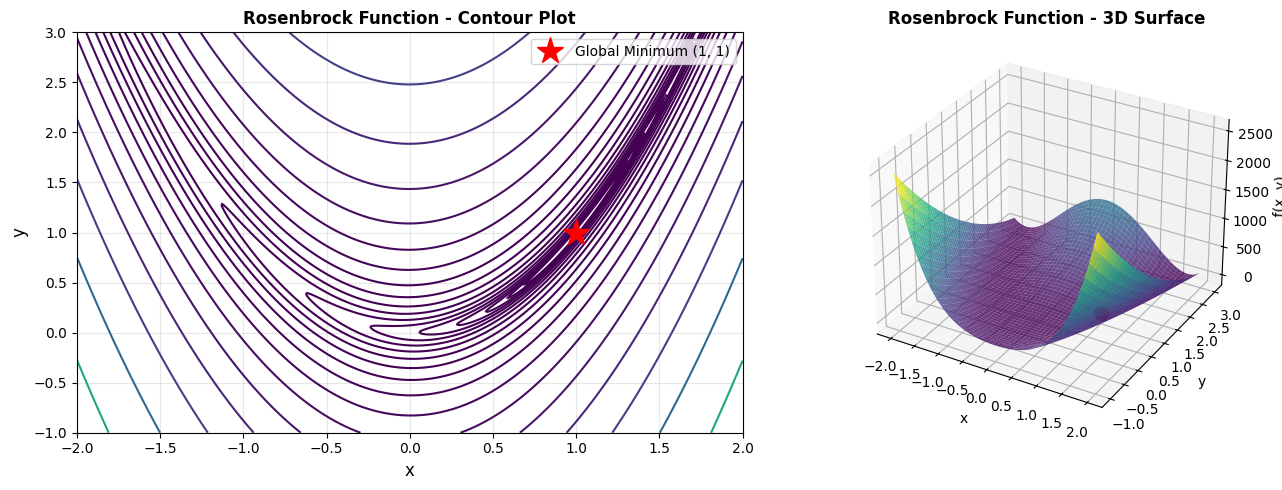

Global minimum:
  Location: (1, 1)
  Value:    0

 Finding Minimum of Rosenbrock Function:


,Method,Result,Error
0,BFGS,"[0.999999944, 0.999999888]","[-5.6e-08, -1.12e-07]"
1,Nelder-Mead,"[0.999999998, 0.999999995]","[-2e-09, -5e-09]"
2,Powell,"[0.99999999999999, 0.99999999999998]","[-1e-14, -2e-14]"


In [18]:
# Rosenbrock function
def rosenbrock(params):
    n = len(params)
    F = 0
    for i in range(n-1):
        F += 100 * (params[i + 1] - params[i] * params[i])**2 + (1 - params[i])**2
    return F

# Visualize the function
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(14, 5))

# Contour plot
ax1 = fig.add_subplot(121)
contour = ax1.contour(X, Y, Z, levels=np.logspace(-1, 3.5, 20), cmap='viridis')
ax1.plot(1, 1, 'r*', markersize=20, label='Global Minimum (1, 1)')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Rosenbrock Function - Contour Plot', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3D surface
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax2.scatter([1], [1], [0], color='red', s=100, label='Minimum')
ax2.set_xlabel('x', fontsize=10)
ax2.set_ylabel('y', fontsize=10)
ax2.set_zlabel('f(x, y)', fontsize=10)
ax2.set_title('Rosenbrock Function - 3D Surface', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Global minimum:")
print(f"  Location: (1, 1)")
print(f"  Value:    {rosenbrock([1, 1])}")

initial = Array[Double]([0.0, 0.0])
lower = Array[Double]([-2.048, -2.048])
upper = Array[Double]([2.048, 2.048])

rosenbrock_net = Func[Array[Double], Double](rosenbrock)

bfgs = BFGS(rosenbrock_net, 2, initial, lower, upper)
bfgs.Minimize()
bfgs_soln = bfgs.BestParameterSet.Values

nelder = NelderMead(rosenbrock_net, 2, initial, lower, upper)
nelder.Minimize()
nelder_soln = nelder.BestParameterSet.Values

powell = Powell(rosenbrock_net, 2, initial, lower, upper)
powell.Minimize()
powell_soln = powell.BestParameterSet.Values

print('\n'  + " Finding Minimum of Rosenbrock Function:")

table = pd.DataFrame([
    {'Method': 'BFGS',
                'Result': np.round(bfgs_soln, 9),
                'Error': np.round(list(bfgs_soln) - np.array([1, 1]), 9)},
        {'Method': 'Nelder-Mead',
                'Result': np.round(nelder_soln,9),
                'Error': np.round(list(nelder_soln) - np.array([1, 1]), 9)},
        {'Method': 'Powell',
                'Result': np.round(powell_soln, 14),
                'Error': np.round(list(powell_soln) - np.array([1, 1]), 14)}])

display(table)


## 4. Global Optimization
Global optimization explores the full domain and is less sensitive to initial values than local optimization.

### Methods Available
- Differential Evolution
- Multi-Start
- Multi-Start Single Linkage (MLSL)
- Particle Swarm
- Shuffled Complex Evolution
- Simulated Annealing

Below we apply these to a 5D Rosenbrock objective.

In [19]:
# 5D objective visualized via 2D slice at fixed remaining coordinates.
lower = Array[Double]([-2.048, -2.048, -2.048, -2.048, -2.048])
upper = Array[Double]([2.048, 2.048, 2.048, 2.048, 2.048])

# Optimize with particle swarm
particle = ParticleSwarm(rosenbrock_net, 5, lower, upper)
particle.PopulationSize = 100
particle.MaxIterations = 100000
particle.Minimize()
particle_soln = particle.BestParameterSet.Values

# Optimize with simulated annealing
anneling = SimulatedAnnealing(rosenbrock_net, 5, lower, upper)
anneling.Minimize()
anneling_soln = anneling.BestParameterSet.Values

# Optimize with differential evolution
de = DifferentialEvolution(rosenbrock_net, 5, lower, upper)
de.PopulationSize = 100
de.MaxIterations = 5000
de.Minimize()
de_soln = de.BestParameterSet.Values

# Optimize with MultiStart
ms_initial = Array[Double]([0.0, 0.0, 0.0, 0.0, 0.0]) # Requires an intial guess with the same number of dimensions as the problem
ms = MultiStart(rosenbrock_net, 5, ms_initial, lower, upper, LocalMethod.BFGS) # Requires a local method to use for the local optimization steps
ms.MaxIterations = 50  # number of local starts
ms.Minimize()
ms_soln = ms.BestParameterSet.Values

# Optimize with MLSL
mlsl = MLSL(rosenbrock_net, 5, ms_initial, lower, upper, LocalMethod.BFGS) # Requires an itital guess with the same number of dimensions as the problem
mlsl.SampleSize = 30
mlsl.MaxIterations = 200
mlsl.Minimize()
mlsl_soln = mlsl.BestParameterSet.Values

# Optimize with Shuffled Complex Evolution
sce = ShuffledComplexEvolution(rosenbrock_net, 5, lower, upper)
sce.Complexes = 5
sce.MaxIterations = 2000
sce.Minimize()
sce_soln = sce.BestParameterSet.Values

print('\n'  + " Finding Minimum of Rosenbrock Function:")

table = pd.DataFrame([
    {'Method': 'Particle Swarm',
                'Result': np.round(particle_soln, 14),
                'Error': np.round(list(particle_soln) - np.array([1, 1, 1, 1, 1]), 14)},
        {'Method': 'Simulated Annealing',
                'Result': np.round(anneling_soln, 4),
                'Error': np.round(list(anneling_soln) - np.array([1, 1, 1, 1, 1]), 4)},
        {'Method': 'Differential Evolution',
                'Result': np.round(de_soln, 14),
                'Error': np.round(list(de_soln) - np.array([1, 1, 1, 1, 1]), 14)},
        {'Method': 'MultiStart',
                'Result': np.round(ms_soln, 14),
                'Error': np.round(list(ms_soln) - np.array([1, 1, 1, 1, 1]), 14)},
        {'Method': 'MLSL',
                'Result': np.round(mlsl_soln, 14),
                'Error': np.round(list(mlsl_soln) - np.array([1, 1, 1, 1, 1]), 14)},
        {'Method': 'Shuffled Complex Evolution',
                'Result': np.round(sce_soln, 14),
                'Error': np.round(list(sce_soln) - np.array([1, 1, 1, 1, 1]), 14)}
                ])

display(table)



 Finding Minimum of Rosenbrock Function:


,Method,Result,Error
0,Particle Swarm,"[0.99999999999999, 0.99999999999999, 0.9999999...","[-1e-14, -1e-14, -2e-14, -4e-14, -9e-14]"
1,Simulated Annealing,"[1.0001, 1.0002, 1.0005, 1.001, 1.002]","[0.0001, 0.0002, 0.0005, 0.001, 0.002]"
2,Differential Evolution,"[1.00000255191575, 1.00000525614079, 1.0000132...","[2.55191575e-06, 5.25614079e-06, 1.322441551e-..."
3,MultiStart,"[0.99999999100071, 0.99999998181046, 0.9999999...","[-8.99929e-09, -1.818954e-08, -3.78976e-08, -7..."
4,MLSL,"[0.99999998707606, 0.99999997427332, 0.9999999...","[-1.292394e-08, -2.572668e-08, -5.161203e-08, ..."
5,Shuffled Complex Evolution,"[0.99999999999666, 0.9999999999952, 0.99999999...","[-3.34e-12, -4.8e-12, -6.06e-12, -1.152e-11, -..."


In [20]:
# Ackley and Beale examples with visualizations.

## 5. Constrained Optimization (Augmented Lagrange)

We will now use the Rosenbrock function constrained to a disk to test the Augmented Lagrange Algorithm.

In [21]:
def constraint(x):
    return x[0]*x[0] + x[1]*x[1]

def rosenbrock_disk(params):
    return np.power(1 - params[0], 2) + 100*(np.power(params[1] - params[0]*params[0], 2))

rosenbrock_disk_net = Func[Array[Double], Double](rosenbrock_disk)
constraint_net = Func[Array[Double], Double](constraint)

# Set up inner solver
initial = Array[Double]([0.0, 0.0])
lower = Array[Double]([-1.5, -1.5])
upper = Array[Double]([1.5, 1.5])
inner_solver = BFGS(rosenbrock_disk_net, 2, initial, lower, upper)

# Set up constraint
constraint = Constraint(constraint_net, 2, 2, ConstraintType.LesserThanOrEqualTo)

# Solve
constraint_list = List[IConstraint]()
constraint_list.Add(constraint)

solver = AugmentedLagrange(rosenbrock_disk_net, inner_solver, constraint_list)
solver.Minimize()
soln = solver.BestParameterSet.Values

# Results
print('\n'  + " Finding Minimum of Rosenbrock Function Constrained to a Disk:")

table = pd.DataFrame([
    {'Method': 'Augmented Lagrange',
                'Result': np.round(soln, 6),
                'Error': np.round(list(soln) - np.array([1, 1]), 6)},
])
display(table)



 Finding Minimum of Rosenbrock Function Constrained to a Disk:


,Method,Result,Error
0,Augmented Lagrange,"[0.999998, 0.999996]","[-2e-06, -4e-06]"


## Summary

### When to Use Each Method
Table includes root finding, integration, local, global, and constrained optimization methods covered above.
|Category|Method|Best Use|
|---|---|---|
|Root Finding | Bisection| Robust, bracketed roots|
|Root Finding | Brent | Faster than bisection, bracketed roots |
|Integration | Gauss-Legendre | High accuracy for smooth functions |
|Integration | Simpson | Good accuracy/speed tradeoff|
|Local Optimization | BFGS | Smooth objectives, fast convergence|
|Local Optimization| Nelder-Mead | Noisy/derivative free |
|Global Optimization | Particle Swarm | Multimodal, easy tuning |
|Global Optimization| DE | Robust, global search |
|Global Optimization | SCE | Hydrolofic calibration |
|Constrained | Augmented Lagrange | Explicit constraints |

## Practical Tips
- Start with broad bounds to avoid excluding the true optimum.
- Use multiple starts for non-convex objectives.
- For noisy objectives, prefer derivative-free methods (Nelder-Mead, Powell).
- Always verify solutions by evaluating the objective value at the returned parameters.

## Next Steps
- **07_statistics.ipynb**: Hypothesis testing and transformations.
- **05_mcmc_advanced.ipynb**: When uncertainty quantification is needed.

## Exercise
1. Fit Rosenbrock in 3D with BFGS and DE.
2. Compare runtime and final error.
3. Try narrower bounds and observe convergence.

